In [4]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
pip install behave==1.2.6

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
pip install sentence-transformers torch

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Loaded Behave version: 1.2.6
Loaded 'sentence-transformers' module.
Reading 'Groups_BDD_Results.xlsx'...
Loading model 'sentence-transformers/all-MiniLM-L6-v2'...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5845.76it/s]


Generating sentence embeddings...


Batches: 100%|██████████| 15/15 [00:02<00:00,  5.30it/s]



             EXECUTION & SYNTAX METRICS           
 Total Scenarios Processed : 454
 Total Executable Passed    : 454
 Final Executable Rate      : 100.00%

         COSINE SIMILARITY METRICS (MiniLM)       
 Mean Cosine Similarity   : 0.7390
 Median Cosine Similarity : 0.7551
 Min Cosine Similarity    : 0.3499
 Max Cosine Similarity    : 0.8757


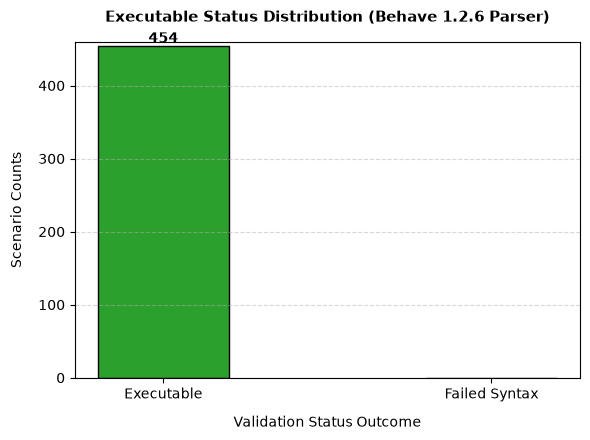

In [7]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================\n
# 1. DEPENDENCY CHECKS
# ==========================================\n
try:
    import behave
    from behave.parser import parse_feature, ParserError
    print(f"Loaded Behave version: {behave.__version__}")
except ImportError:
    print("\n[ERROR] 'behave' is not installed. Run: pip install behave==1.2.6\n")
    sys.exit(1)

try:
    from sentence_transformers import SentenceTransformer, util
    print("Loaded 'sentence-transformers' module.")
except ImportError:
    print("\n[ERROR] 'sentence-transformers' is not installed. Run: pip install sentence-transformers torch\n")
    sys.exit(1)

# ==========================================\n
# 2. DATA IMPORT
# ==========================================\n
EXCEL_FILE_PATH = "Groups_BDD_Results.xlsx"

if not os.path.exists(EXCEL_FILE_PATH):
    raise FileNotFoundError(f"Target Excel file '{EXCEL_FILE_PATH}' was not found.")

print(f"Reading '{EXCEL_FILE_PATH}'...")
df = pd.read_excel(EXCEL_FILE_PATH)

total_scenarios = 0
passed_scenarios = 0
evaluation_results = []
failure_reasons = []

prompts_list = []
responses_list = []

# ==========================================\n
# 3. BEHAVE 1.2.6 SYNTAX VALIDATION
# ==========================================\n
for idx, row in df.iterrows():
    if len(row) < 3 or pd.isna(row.iloc[2]):
        continue
        
    user_story_id = str(row.iloc[0]).strip()
    prompt_text = str(row.iloc[1]).strip() if not pd.isna(row.iloc[1]) else ""
    scenario_text = str(row.iloc[2]).strip()
    
    if not scenario_text:
        continue
        
    total_scenarios += 1
    prompts_list.append(prompt_text)
    responses_list.append(scenario_text)
    
    # Format scenario text into a complete Behave Feature document
    feature_title = user_story_id.split(":")[-1].strip() if ":" in user_story_id else user_story_id
    full_feature_content = f"Feature: {feature_title}\n\n  {scenario_text}\n"
    
    try:
        parsed_feature = parse_feature(full_feature_content)
        if parsed_feature and len(parsed_feature.scenarios) > 0:
            evaluation_results.append("Executable")
            passed_scenarios += 1
        else:
            evaluation_results.append("Failed Syntax")
            failure_reasons.append((idx, "No valid scenarios found in feature block"))
            
    except ParserError as pe:
        evaluation_results.append("Failed Syntax")
        failure_reasons.append((idx, str(pe)))
    except Exception as e:
        evaluation_results.append("Failed Syntax")
        failure_reasons.append((idx, str(e)))

# ==========================================\n
# 4. COSINE SIMILARITY EVALUATION
# ==========================================\n
print("Loading model 'sentence-transformers/all-MiniLM-L6-v2'...")
model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

print("Generating sentence embeddings...")
prompt_embeddings = model.encode(prompts_list, convert_to_tensor=True, show_progress_bar=True)
response_embeddings = model.encode(responses_list, convert_to_tensor=True, show_progress_bar=True)

# Calculate paired cosine similarity for corresponding (Prompt, Response) pairs
cosine_matrix = util.cos_sim(prompt_embeddings, response_embeddings)
cosine_scores = cosine_matrix.diagonal().cpu().numpy()

# Store cosine similarity values back to DataFrame
df["Cosine_Similarity"] = cosine_scores

# ==========================================\n
# 5. METRICS SUMMARY & REPORTING
# ==========================================\n
executable_rate = (passed_scenarios / total_scenarios * 100) if total_scenarios > 0 else 0

mean_cos_sim = cosine_scores.mean()
median_cos_sim = pd.Series(cosine_scores).median()
min_cos_sim = cosine_scores.min()
max_cos_sim = cosine_scores.max()

print("\n" + "="*50)
print("             EXECUTION & SYNTAX METRICS           ")
print("="*50)
print(f" Total Scenarios Processed : {total_scenarios}")
print(f" Total Executable Passed    : {passed_scenarios}")
print(f" Final Executable Rate      : {executable_rate:.2f}%")

print("\n" + "="*50)
print("         COSINE SIMILARITY METRICS (MiniLM)       ")
print("="*50)
print(f" Mean Cosine Similarity   : {mean_cos_sim:.4f}")
print(f" Median Cosine Similarity : {median_cos_sim:.4f}")
print(f" Min Cosine Similarity    : {min_cos_sim:.4f}")
print(f" Max Cosine Similarity    : {max_cos_sim:.4f}")
print("="*50)

if failure_reasons:
    print(f"\nSample Syntax Errors ({len(failure_reasons)} total failed):")
    for row_idx, err in failure_reasons[:3]:
        print(f" - Row {row_idx + 2}: {err}")

# Plot Executable Status Distribution Chart
plt.figure(figsize=(6, 4.5))
categories = ["Executable", "Failed Syntax"]
counts = [evaluation_results.count(cat) for cat in categories]

bars = plt.bar(categories, counts, color=['#2ca02c', '#d62728'], width=0.4, edgecolor='black')
plt.title("Executable Status Distribution (Behave 1.2.6 Parser)", fontsize=11, fontweight='bold', pad=15)
plt.xlabel("Validation Status Outcome", fontsize=10, labelpad=10)
plt.ylabel("Scenario Counts", fontsize=10, labelpad=10)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.ylim(0, max(total_scenarios + 5, 10))

for bar in bars:
    height = bar.get_height()
    if height > 0:
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
                 f'{height}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()